# Bài tập thực hành: Linear / Logistic / Softmax Regression

_Dựa trên nội dung Chapter 4 – Training Models (Hands-On ML 3rd edition)_

**Hướng dẫn:** Hoàn thành các ô code có ghi `# YOUR CODE HERE`. Mỗi bài đều có gợi ý (hints) để hỗ trợ.

## Setup

In [1]:
import sys
assert sys.version_info >= (3, 7)

import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

np.random.seed(42)  # để kết quả reproducible

---
# Bài 1 — Linear Regression cơ bản

Trong bài này ta sẽ làm việc với dữ liệu tuyến tính được tạo giả lập theo công thức:

$$y = 4 + 3x_1 + \text{noise}$$

Đây chính là dữ liệu được sử dụng trong Chapter 4 của sách.

### Tạo dữ liệu

Chạy cell sau để tạo dữ liệu (giống hệt trong sách):

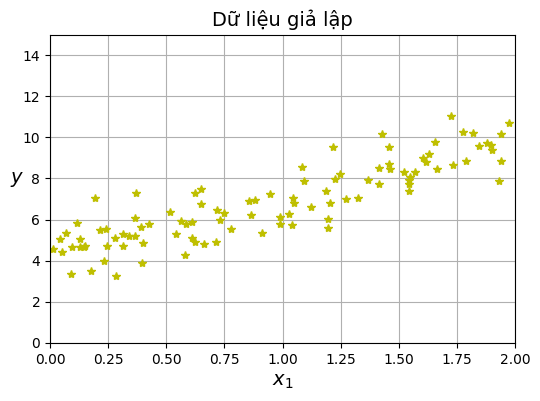

In [2]:
np.random.seed(42)
m = 100  # số mẫu
X = 2 * np.random.rand(m, 1)  # mảng 2 chiều có shape(100,1) tức 100 samples 1 feature // nhân 2 để scale
y = 4 + 3 * X + np.random.randn(m, 1)

# Vẽ dữ liệu
plt.figure(figsize=(6, 4))
plt.plot(X, y, "y*") # em nghịch cho nó trông bling
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.title("Dữ liệu giả lập")
plt.show()

### Bài 1a — Giải bằng Normal Equation (thủ công)

Dùng công thức Normal Equation:

$$\hat{\theta} = (\mathbf{X}_b^T \mathbf{X}_b)^{-1} \mathbf{X}_b^T \mathbf{y}$$

**Gợi ý:**
- Dùng `sklearn.preprocessing.add_dummy_feature` để thêm cột $x_0 = 1$ vào X
- Dùng `np.linalg.inv()` để tính ma trận nghịch đảo
- Toán tử `@` dùng để nhân ma trận trong NumPy

In [12]:
from sklearn.preprocessing import add_dummy_feature

# Bước 1: Thêm bias term x0 = 1
X_b = add_dummy_feature(X)
# Có y = theta0 + theta1*x, phải chuyển sang dạng ma trận để máy tính hiểu được: X@theta
# ta cần thêm một cột toàn số 1 vào X nhằm đưa hệ số theta0(điểm cắt Oy) vào phép nhân mtran trên

# Bước 2: Tính theta_best bằng Normal Equation
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y 
# nhân mtran trong đstt: A@B hoặc A.dot(B)
# X mũ T: mtran chuyển vị, hàng<->cột
# X mũ -1: mtran nghịch đảo


# In kết quả
print("theta_best =", theta_best)
# theta_best là bộ tham số (theta0, theta1) để đường thẳng fit dlieu sát nhất

theta_best = [[4.21509616]
 [2.77011339]]


### Bài 1b — So sánh với sklearn

Dùng `LinearRegression` từ sklearn để fit cùng dữ liệu, rồi so sánh `intercept_` và `coef_` với kết quả Normal Equation.

**Gợi ý:** `lin_reg.intercept_` là $\theta_0$, `lin_reg.coef_` là $\theta_1$

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

# In intercept_ và coef_
print("Intercept:", lin_reg.intercept_) # intercept: điểm cắt Oy, chính là theta0
print("Coef:", lin_reg.coef_) # coef - coefficient: hệ số (của x), chính là theta1

Intercept: [4.21509616]
Coef: [[2.77011339]]


### Bài 1c — Vẽ đường hồi quy

Dùng mô hình đã train để dự đoán y cho X_new = [[0], [2]], rồi vẽ đường hồi quy lên scatter plot.

**Gợi ý:** Dùng `plt.plot(X_new, y_predict, "r-")` để vẽ đường đỏ

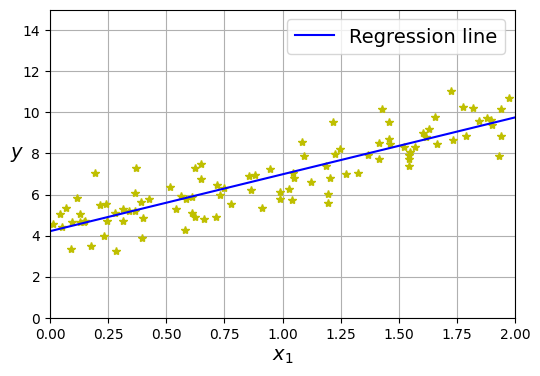

In [ ]:
X_new = np.array([[0], [2]]) # tạo ra 2 điểm cụ thể là x0 = 0, x1 = 2

# Dự đoán y cho X_new
y_predict = lin_reg.predict(X_new) # y0, y1


# Vẽ biểu đồ
plt.figure(figsize=(6, 4))
plt.plot(X, y, "y*")    # Vẽ dữ liêu gốc
plt.plot(X_new, y_predict, "b-", label="Regression line")   # Vẽ đường hồi quy
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend()    # chú giải
plt.show()



---
# Bài 2 — Batch Gradient Descent

Implement thuật toán Batch Gradient Descent thủ công để tìm $\theta$ cho cùng dữ liệu tuyến tính ở Bài 1.

Công thức cập nhật:

$$\theta_{\text{next}} = \theta - \eta \cdot \frac{2}{m} \mathbf{X}_b^T (\mathbf{X}_b \theta - \mathbf{y})$$

### Bài 2a — Implement Batch GD

Dùng learning rate $\eta = 0.1$ và `n_epochs = 1000`.

**Gợi ý:**
- Khởi tạo theta ngẫu nhiên: `theta = np.random.randn(2, 1)`
- Trong vòng lặp: tính gradients rồi cập nhật theta

In [ ]:
eta = 0.1  # learning rate
n_epochs = 1000
m = len(X_b)  # đảm bảo X_b đã được tạo ở Bài 1a

np.random.seed(42)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
    # YOUR CODE HERE
    # gradients = ...
    # theta = ...
    pass

# In theta
# print("theta =", theta)

### Bài 2b — So sánh các learning rate

Vẽ 3 subplot thể hiện quá trình hội tụ của GD với 3 learning rate:
$\eta = 0.02$, $\eta = 0.1$, $\eta = 0.5$

**Gợi ý:**
- Dùng `plt.subplot(1, 3, i)` để tạo 3 ô
- Ở mỗi subplot, vẽ 20 đường dự đoán đầu tiên (màu gradient) lên dữ liệu
- Dùng `plt.cm.OrRd(epoch / n_shown + 0.15)` cho hiệu ứng màu

In [ ]:
import matplotlib as mpl

X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        # YOUR CODE HERE — tính gradients và cập nhật theta
        # gradients = ...
        # theta = ...
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")

np.random.seed(42)
theta = np.random.randn(2, 1)

plt.figure(figsize=(10, 4))
# YOUR CODE HERE — vẽ 3 subplot với eta = 0.02, 0.1, 0.5
# plt.subplot(...)
# plot_gradient_descent(...)
plt.tight_layout()
plt.show()

### Bài 2c — Nhận xét

Trong ô markdown bên dưới, hãy viết nhận xét về ảnh hưởng của learning rate đối với quá trình hội tụ:

**Nhận xét của bạn:** *(viết ở đây)*

---
# Bài 3 — SGD và Mini-batch Gradient Descent

Tiếp tục sử dụng dữ liệu tuyến tính từ Bài 1.

### Bài 3a — Stochastic Gradient Descent thủ công

Implement SGD với **learning schedule** giảm dần:

$$\eta(t) = \frac{t_0}{t + t_1}$$

Với $t_0 = 5$, $t_1 = 50$, 50 epochs.

**Gợi ý:**
- Mỗi epoch, duyệt qua m iteration (mỗi iteration chọn 1 mẫu ngẫu nhiên)
- Với SGD, KHÔNG chia gradient cho m
- `random_index = np.random.randint(m)`

In [ ]:
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
    for iteration in range(m):
        # YOUR CODE HERE
        # random_index = ...
        # xi = X_b[random_index : random_index + 1]
        # yi = y[random_index : random_index + 1]
        # gradients = ...
        # eta = learning_schedule(...)
        # theta = ...
        pass

# print("SGD theta =", theta)

### Bài 3b — So sánh với SGDRegressor của sklearn

Dùng `SGDRegressor` với `max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42` rồi so sánh kết quả.

**Gợi ý:** `sgd_reg.intercept_` và `sgd_reg.coef_`

In [ ]:
from sklearn.linear_model import SGDRegressor

# YOUR CODE HERE
# sgd_reg = SGDRegressor(...)
# sgd_reg.fit(X, y.ravel())

# print("intercept:", sgd_reg.intercept_)
# print("coef:", sgd_reg.coef_)

### Bài 3c — Mini-batch Gradient Descent

Implement Mini-batch GD với `batch_size = 20`, 50 epochs.

**Gợi ý:**
- Mỗi epoch shuffle dữ liệu, rồi chia thành các mini-batch
- Gradient tính trên mini-batch: `2/batch_size * X_batch.T @ (X_batch @ theta - y_batch)`

In [ ]:
n_epochs = 50
batch_size = 20
t0, t1 = 200, 1000

def learning_schedule_mb(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)
t = 0

for epoch in range(n_epochs):
    # YOUR CODE HERE
    # shuffled_indices = np.random.permutation(m)
    # X_b_shuffled = X_b[shuffled_indices]
    # y_shuffled = y[shuffled_indices]
    # for i in range(0, m, batch_size):
    #     ...
    pass

# print("Mini-batch GD theta =", theta)

---
# Bài 4 — Logistic Regression

Dùng Iris dataset (giống Chapter 4 trong sách) để phân loại **Iris-Virginica** vs. **NOT Virginica** (bài toán binary classification).

Feature sử dụng: **petal width** (chiều rộng cánh hoa).

### Tải dữ liệu Iris

> **📌 Lưu ý:** Iris dataset **có sẵn trong thư viện scikit-learn**, không cần tải hay lưu file riêng.
> Chỉ cần gọi `load_iris()` là có ngay 150 mẫu hoa Iris với 4 features (sepal length/width, petal length/width) và 3 classes (Setosa, Versicolor, Virginica).
> Đảm bảo máy đã cài `scikit-learn` (`pip install scikit-learn`) trước khi chạy.

In [ ]:
from sklearn.datasets import load_iris

# Iris dataset có sẵn trong sklearn, không cần download
iris = load_iris(as_frame=True)
print("Feature names:", list(iris.data.columns))
print("Target names:", list(iris.target_names))
print("Shape:", iris.data.shape)

### Bài 4a — Train Logistic Regression

- Lấy feature **petal width (cm)** làm X
- Tạo nhãn y: 1 nếu Virginica (target == 2), 0 nếu không
- Fit `LogisticRegression` với `random_state=42`

**Gợi ý:** Dùng `iris["data"][["petal width (cm)"]].values` để lấy X

In [ ]:
from sklearn.linear_model import LogisticRegression

# YOUR CODE HERE
# X_iris = ...  # petal width
# y_iris = ...  # 1 nếu Virginica, 0 nếu không

# log_reg = LogisticRegression(random_state=42)
# log_reg.fit(...)

### Bài 4b — Vẽ đường xác suất sigmoid

Tạo mảng `X_new_iris` từ 0 đến 3 (1000 điểm), dùng `log_reg.predict_proba()` để tính xác suất, rồi vẽ.

**Gợi ý:**
- `X_new_iris = np.linspace(0, 3, 1000).reshape(-1, 1)`
- `y_proba = log_reg.predict_proba(X_new_iris)` trả về mảng shape (1000, 2)
- Cột 1 là P(Virginica)

In [ ]:
# YOUR CODE HERE
# X_new_iris = ...
# y_proba = ...

# plt.figure(figsize=(8, 4))
# plt.plot(X_new_iris, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica")
# plt.plot(X_new_iris, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica")
# plt.xlabel("Petal width (cm)")
# plt.ylabel("Probability")
# plt.legend()
# plt.grid()
# plt.show()

### Bài 4c — Dự đoán

Dùng mô hình để dự đoán cho `petal_width = 1.7` và `petal_width = 2.0`.

In ra class dự đoán và xác suất.

In [ ]:
# YOUR CODE HERE
# Dự đoán cho petal_width = 1.7
# ...

# Dự đoán cho petal_width = 2.0
# ...

---
# Bài 5 — Softmax Regression

Dùng Iris dataset với **2 features** (petal length, petal width) để phân loại **3 classes** (Setosa, Versicolor, Virginica).

Sklearn sẽ tự động dùng Softmax khi `multi_class="multinomial"`.

### Bài 5a — Train Softmax Regression

- Lấy 2 features: petal length, petal width
- Target: 3 classes gốc (0, 1, 2)
- Dùng `LogisticRegression(multi_class="multinomial", solver="lbfgs", C=10, random_state=42)`

In [ ]:
# YOUR CODE HERE
# X_softmax = iris["data"][["petal length (cm)", "petal width (cm)"]].values
# y_softmax = iris["target"].values

# softmax_reg = LogisticRegression(multi_class="multinomial", solver="lbfgs", C=10, random_state=42)
# softmax_reg.fit(X_softmax, y_softmax)

### Bài 5b — Dự đoán và xác suất

Dự đoán class và xác suất cho mẫu `petal_length=5, petal_width=2`.

In [ ]:
# YOUR CODE HERE
# sample = ...
# print("Predicted class:", softmax_reg.predict(sample))
# print("Probabilities:", softmax_reg.predict_proba(sample))

### Bài 5c — Vẽ Decision Boundary

Vẽ biểu đồ 2D với decision boundary giữa 3 classes.

**Gợi ý:**
- Tạo meshgrid từ petal length (0–7) và petal width (0–3.5)
- Dùng `softmax_reg.predict()` trên meshgrid
- Dùng `plt.contourf()` để tô màu vùng quyết định

In [ ]:
from matplotlib.colors import ListedColormap

# YOUR CODE HERE
# custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])
# x0_grid = np.linspace(0, 7, 500)
# x1_grid = np.linspace(0, 3.5, 200)
# x0_mesh, x1_mesh = np.meshgrid(x0_grid, x1_grid)
# X_grid = np.c_[x0_mesh.ravel(), x1_mesh.ravel()]

# y_pred_grid = softmax_reg.predict(X_grid).reshape(x0_mesh.shape)

# plt.figure(figsize=(8, 6))
# plt.contourf(x0_mesh, x1_mesh, y_pred_grid, cmap=custom_cmap, alpha=0.8)
# plt.scatter(...)
# plt.xlabel("Petal length (cm)")
# plt.ylabel("Petal width (cm)")
# plt.title("Softmax Regression Decision Boundary")
# plt.show()

---
## 🎉 Hoàn thành!

Chúc mừng bạn đã hoàn thành bài tập về Linear, Logistic và Softmax Regression.